# MeteoScreening `TS_FF1_0.05_2` (2020-2025) from database (influxdb)

***
**Site**: CH-LAE &nbsp;&nbsp;|&nbsp;&nbsp; **Variable**: `TS_FF1_0.05_2` &nbsp;&nbsp;|&nbsp;&nbsp; **Sensor**: METER **TEROS 12**, the same physical probe that reports `SWC_FF1_0.05_1`, installed 19 Mar 2020 at 0.05 m &nbsp;&nbsp;|&nbsp;&nbsp; **Period**: 2020-2025
**Derived from**: diive notebook template `DatabaseInfluxStepwiseMeteoScreening.ipynb` (version `9`, 15 Jul 2026), via `TS_FF1_0.05_1_2020-2025.ipynb`
**Author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook
Download raw soil temperature from the InfluxDB database, remove the worst outliers on the **high-resolution** data, resample to 30MIN, and upload the result back to the database. Screening uses `StepwiseMeteoScreeningDb` from [diive](https://github.com/holukas/diive) (`diive/preprocessing/qaqc/meteoscreening.py`); download and upload use diive's in-house InfluxDB engine (`InfluxIO`, in `diive/core/io/db/influx`).

**Flow:** download (`InfluxIO`) → screen on high-res data (`diive`) → resample to 30MIN → upload.

**Scope is deliberately narrow.** The raw record is millions of rows, so anything done here is expensive. This notebook only takes out what is unambiguously wrong at high resolution — the April 2024 SDI-12 decode garbage (absolute limits) and the seven December 2025 logger-artefact minutes (manual removal) — and hands over a clean 30MIN series. Everything else (sensor comparisons, level/offset questions, gap handling, homogenisation across sensor generations) is settled later in `30_PRODUCTS/`, **on the half-hourly data**, where it costs a fraction as much.

**Outlier detection is stepwise:** run a test, inspect its preview plot, then commit it with `mscr.addflag()`. Re-run with different parameters as often as you like before committing. Run only the tests a variable actually needs. At the end all committed flags are aggregated into one overall quality flag `QCF`.

> **Which sensor this is.** In this profile the replicate suffix names the sensor family, not the depth: `_1` = the water-potential sensors of the 19 Mar 2020 install (MPS-2 at 0.05/0.1/0.6 m, TEROS 21 at 0.2/0.3/0.5 m), `_2` = the TEROS 12 probes that also report `SWC_FF1_<depth>_1`, `_3`/`_4` = Campbell 109 thermistors added at the March 2021 logger rebuild. **This one is a METER TEROS 12 (the same probe that reports SWC_FF1_0.05_1).**

> **Database access** needs the `influxdb-client` package, which this project pulls in via the **`diive[db]` extra** (declared in `pyproject.toml`). diive *also* ships a `db` dependency group, but dependency groups are local to the project that declares them — `uv sync --group db` only works inside the diive repo, not from here.

## ⏱️ Timestamp convention (important)
The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`** (the stamp marks the *end* of the averaging interval). Getting this right is the one thing that must not go wrong: the value written back to the database depends on it, and so does every window in `REMOVE_DATES`.

The single knob is `TIMEZONE_OFFSET_TO_UTC_HOURS` (set in *User settings*). It is applied **identically** on download and on upload:

| Stage | Timezone | Convention | Done by |
|---|---|---|---|
| Database | UTC | `TIMESTAMP_END` | InfluxDB |
| After `dbc.download(..., timezone_offset_to_utc_hours=N)` | local (UTC+N) | `TIMESTAMP_END` | InfluxIO |
| During screening | local | `TIMESTAMP_MIDDLE` (converted internally) | `StepwiseMeteoScreeningDb` |
| After `mscr.resample()` | local | back to `TIMESTAMP_END` | diive |
| After `dbc.upload_singlevar(..., timezone_offset_to_utc_hours=N)` | UTC | `TIMESTAMP_END` | InfluxIO |

**One place where this bites.** `REMOVE_DATES` is matched against `TIMESTAMP_MID`, not `TIMESTAMP_END`: `StepwiseMeteoScreeningDb` hands the series to `ManualRemoval` *after* the internal conversion, so the record whose `TIMESTAMP_END` is `10:39:00` carries the label `10:38:30` inside the test. A bare `'2025-12-19 10:39:00'` would therefore match **nothing** and the removal would silently do nothing. It only matters when removing individual records: a window spanning days has edges far larger than the half-record offset.

## ✏️ User settings (please adjust)

Adjust these before running. What each setting means:

**Site**
- `SITE`, `SITE_LAT`, `SITE_LON`: site ID and coordinates. The coordinates set the day/night split used during screening — not used here, see *Outlier detection*.

**Variable to screen**
- `PROFILE`, `DEPTH`, `REPL`: the sensor's position tags. `FIELD` is assembled from them and is the InfluxDB `_field`. `REPL` changes the sensor *family*, not just the probe.
- `MEASUREMENT`: exactly **one** measurement grouping the variables — `TS` for soil temperature.

**Time range to screen**
- `START`: first timestamp to screen — **is** included.
- `STOP`: upper bound — **is not** included.

**Data settings**
- `TIMEZONE_OFFSET_TO_UTC_HOURS`: the critical timestamp knob — see *Timestamp convention*. Must match how the raw data was logged (`1` for CET winter time) and must be the same value everywhere.
- `DATA_VERSION`: the source data version in the database (`raw`).
- `DIRCONF`: local folder holding the database connection config.

**Resampling**
- `RESAMPLING_FREQ` / `RESAMPLING_AGG`: soil temperature is a **state**, so `'mean'` — never `'sum'`.

**Physical range**
- `TS_MIN`, `TS_MAX`: the absolute-limits test, justified from this sensor's own measured extremes.

**Parameter help**
- `SHOW_PARAM_HELP`: `True` prints the full docstring of each screening method right before it runs.

In [1]:
# --- Site ---
SITE = 'ch-lae'
SITE_LAT = 47.478333  # CH-LAE
SITE_LON = 8.364389  # CH-LAE

# --- Variable to screen ---
# (!) REPL, not DEPTH, is what names the sensor family in this profile:
#       _1  the water-potential sensors of the 19 Mar 2020 install - MPS-2 at 0.05/0.1/0.6 m,
#           TEROS 21 at 0.2/0.3/0.5 m. Six channels.
#       _2  METER TEROS 12, the same probes that report SWC_FF1_<depth>_1. Five channels.
#       _3/_4  Campbell 109 thermistors at 0.05 m, added at the March 2021 logger rebuild.
# This notebook screens: METER TEROS 12 (the same probe that reports SWC_FF1_0.05_1).
PROFILE = 'FF1'  # horizontal position (soil profile)
DEPTH = '0.05'
REPL = '2'  # <-- the sensor family, see above
FIELD = f'TS_{PROFILE}_{DEPTH}_{REPL}'
FIELDS = [FIELD]  # StepwiseMeteoScreeningDb expects a list
MEASUREMENT = 'TS'

# --- Time range to screen ---
# Raw resolution is 10MIN until the March 2021 logger rebuild and 1MIN after, so this
# range is ~2.5 million records. The record starts 2020-04-10 15:00; asking for
# 2020-01-01 simply starts at the first record.
START = '2020-01-01 00:00:01'  # included
STOP = '2026-01-01 00:00:01'  # not included

# --- Data settings ---
DATA_VERSION = 'raw'
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # UTC+01:00 (CET, winter time). Must match how the raw data was logged.
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'

# --- Resampling ---
RESAMPLING_FREQ = '30min'  # screened high-res data is resampled to this frequency
RESAMPLING_AGG = 'mean'  # (!) soil temperature is a state variable, never summed

# --- Physical range of soil temperature at this site, in degC ---
# Measured on this channel over 2020-2025 the raw record spans 0.00 to 80.00 degC - but both
# ends are artefacts, not soil: 0.00 is the failed-SDI-12-read sentinel and 80.00 is April 2024
# decode garbage. The real soil signal at 0.05 m sits inside 1-21 degC, so the limits below cannot
# fire on a measurement and do catch every decode record.
TS_MIN, TS_MAX = -5, 30

# --- Parameter help ---
SHOW_PARAM_HELP = False

## 🤖 Auto settings

### Buckets (do not adjust)

In [2]:
BUCKET_RAW = f'{SITE}_raw'  # source bucket, e.g. 'ch-lae_raw'
BUCKET_PROCESSED = f'{SITE}_processed'  # destination bucket, e.g. 'ch-lae_processed'
print(f'Screening variable:             {FIELD}')
print(f'Source bucket (raw data):       {BUCKET_RAW}')
print(f'Destination bucket (processed): {BUCKET_PROCESSED}')

Screening variable:             TS_FF1_0.05_2
Source bucket (raw data):       ch-lae_raw
Destination bucket (processed): ch-lae_processed


### Imports

In [3]:
import importlib.metadata
import warnings
from datetime import datetime

import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # needs influxdb-client, via the diive[db] extra

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 18:30:58
diive v0.91.0


## ⬇️ Download data from database

### Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

Optional - list all fields available in the measurement (does not check the selected time range). Worth a look here because `TS` also holds the *old* forest-floor sensors (`TS_M5_*` and the Campbell 107s removed on 2021-03-25), which belong to different instruments and must never be spliced onto this one:

In [5]:
display(dbc.show_fields_in_measurement(bucket=BUCKET_RAW, measurement=MEASUREMENT))

> Fields in measurement TS of bucket ch-lae_raw:

> Found 33 fields in measurement TS of bucket ch-lae_raw.

['TS_FF1_0.05_1',
 'TS_FF1_0.05_2',
 'TS_FF1_0.05_3',
 'TS_FF1_0.05_4',
 'TS_FF1_0.1_1',
 'TS_FF1_0.1_2',
 'TS_FF1_0.2_1',
 'TS_FF1_0.2_2',
 'TS_FF1_0.3_1',
 'TS_FF1_0.3_2',
 'TS_FF1_0.5_1',
 'TS_FF1_0.5_2',
 'TS_FF1_0.6_1',
 'TS_FF3_0.05_1',
 'TS_FF3_0.05_2',
 'TS_FF3_0.1_1',
 'TS_FF3_0.2_1',
 'TS_FF3_0.3_1',
 'TS_FF3_0.4_1',
 'TS_FF3_0.5_1',
 'TS_H1_0.05_1',
 'TS_H1_0.15_1',
 'TS_H1_0.1_1',
 'TS_H1_0.2_1',
 'TS_H1_0.3_1',
 'TS_M1_0.05_1',
 'TS_M2_0.05_1',
 'TS_M3_0.05_1',
 'TS_M4_0.05_1',
 'TS_M4_0.15_1',
 'TS_M4_0.1_1',
 'TS_M4_0.3_1',
 'TS_M4_0.5_1']

### Download
Returns three objects:
- `data_simple`: high-res time series, one column per variable (nice to look at).
- `data_detailed`: dict `{varname: DataFrame}` with each variable's time series **and its database tags** - this is what the screening consumes.
- `assigned_measurements`: the auto-detected measurement per variable (a sanity check).

In [6]:
%%time
data_simple, data_detailed, assigned_measurements = dbc.download(
    bucket=BUCKET_RAW,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version=DATA_VERSION,
)

> DOWNLOADING from bucket ch-lae_raw: variables ['TS_FF1_0.05_2'] from measurements ['TS'], data 
version ['raw'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone offset to UTC 1)

> Downloaded data for 1 variables:

CPU times: total: 46.6 s
Wall time: 1min 11s


### Inspect downloaded data

In [7]:
data_simple

,TS_FF1_0.05_2
TIMESTAMP_END,
2020-04-10 15:00:00,12.40
2020-04-10 15:10:00,12.40
2020-04-10 15:20:00,12.50
2020-04-10 15:30:00,12.50
2020-04-10 15:40:00,12.50
...,...
2025-12-31 23:56:00,2.15
2025-12-31 23:57:00,2.20
2025-12-31 23:58:00,2.10


In [8]:
assigned_measurements

{'TS_FF1_0.05_2': 'TS'}

Drop any requested variable that has no data in this period:

In [9]:
vars_not_available = [v for v in FIELDS if v not in data_detailed.keys()]
for rem in vars_not_available:
    FIELDS.remove(rem)
    print(f'Removed {rem} from FIELDS (no data in this period).')
print(f'Data available for: {list(data_detailed.keys())}')
assert FIELD in data_detailed, f'(!) {FIELD} returned no data - nothing to screen'

Data available for: ['TS_FF1_0.05_2']


### Verify download timestamps
Confirm the timestamps look right: **local time** (UTC+`TIMEZONE_OFFSET_TO_UTC_HOURS`), marking the **end** of each averaging interval. The database itself stores UTC - `InfluxIO` applied the offset on download. Eyeball the first/last stamps against the `START`/`STOP` you requested.

In [10]:
for v in data_detailed.keys():
    idx = data_detailed[v].index
    print(f'{v}: index name={idx.name!r}, tz={idx.tz}, freq={idx.freqstr}')
    print(f'   first={idx[0]}   last={idx[-1]}')
print(f'\nApplied UTC offset: +{TIMEZONE_OFFSET_TO_UTC_HOURS}h (timestamps above are local time)')

TS_FF1_0.05_2: index name='TIMESTAMP_END', tz=None, freq=None
   first=2020-04-10 15:00:00   last=2026-01-01 00:00:00

Applied UTC offset: +1h (timestamps above are local time)


### Plot downloaded high-res data

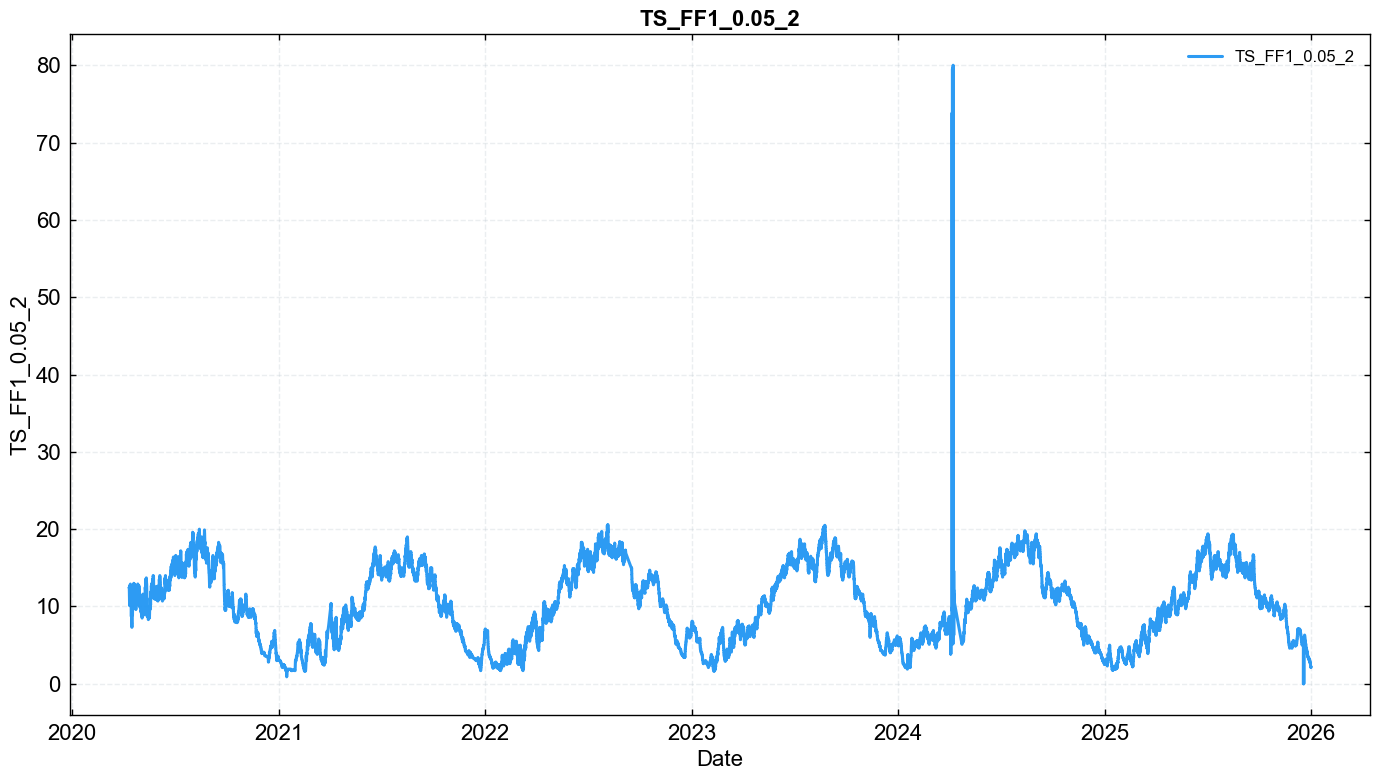

In [11]:
for varname, frame in data_detailed.items():
    dv.plotting.TimeSeries(series=frame[varname]).plot()

## ▶️ Start MeteoScreening with `diive`

> Validating data for variable TS_FF1_0.05_2 ...

> Found 6 unique frequencies across 2502574 records.

> Found frequencies:

> The following frequencies will be used: [60.0, 600.0] (seconds)

> Note that there is more than one single time resolution and all data will be upsampled to match 
the highest found time resolution (60.0S).

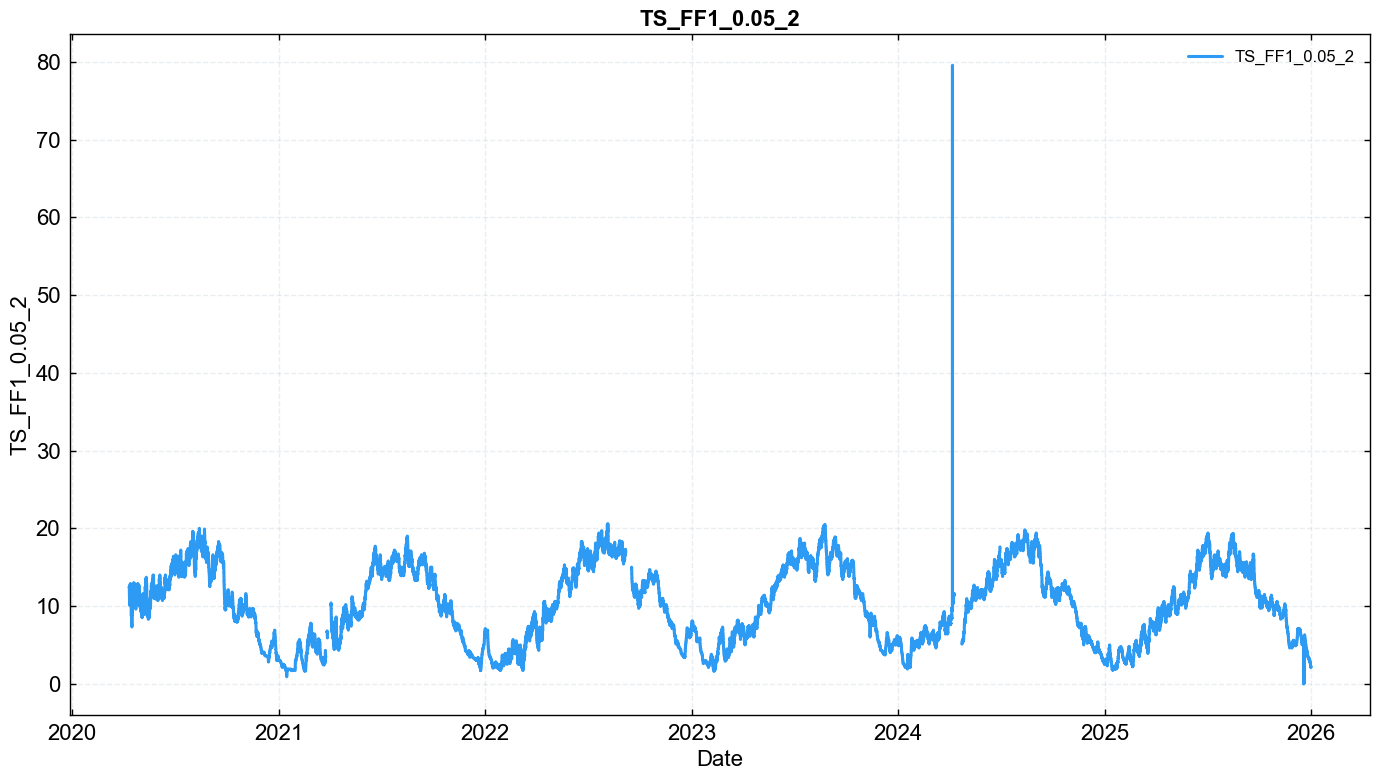

In [12]:
mscr = dv.qaqc.StepwiseMeteoScreeningDb(
    site=SITE,
    data_detailed=data_detailed,
    fields=FIELDS,
    site_lat=SITE_LAT,
    site_lon=SITE_LON,
    utc_offset=TIMEZONE_OFFSET_TO_UTC_HOURS,
)
mscr.showplot_orig()

## 🔍 Outlier detection
Run a test → inspect its preview → commit with `mscr.addflag()`. Only the committed flag of the **most recent** test is added. Skip any test a variable does not need.

**What is committed here**: the **December 2025 logger-artefact minutes** (manual removal), the **April 2024 SDI-12 decode garbage** (absolute limits), and the **missing-values** flag. Why the rest are off:

- **Never split day and night.** Soil temperature does have a diurnal cycle, but at this depth it is damped and lagged relative to the surface, so a solar-geometry split does not line up with it — it would only halve the sample behind every threshold. Every test below runs with `separate_daytime_nighttime=False`.
- **Distribution-wide tests measure the season, not a fault.** A z-score over the whole record asks how far a value sits from the multi-year mean; January at 2 °C and July at 19 °C are both correct.
- **Differencing-based tests are degenerate on this record.** The 10MIN era (to March 2021) is back-filled onto the 1MIN grid by diive, so nine of every ten increments are zero by construction; the 1MIN era is quantised to exactly 0.05 °C and the soil moves a few tenths of a kelvin a day, so ~97 % of minute-to-minute increments are genuinely zero. The rolling MAD a Hampel filter scales its band by is then zero, and raising `n_sigma` cannot help.

In [13]:
mscr.start_outlier_detection()

> Starting step-wise outlier detection for variable TS_FF1_0.05_2 ...

Plot the current cleaned data at any point during detection:

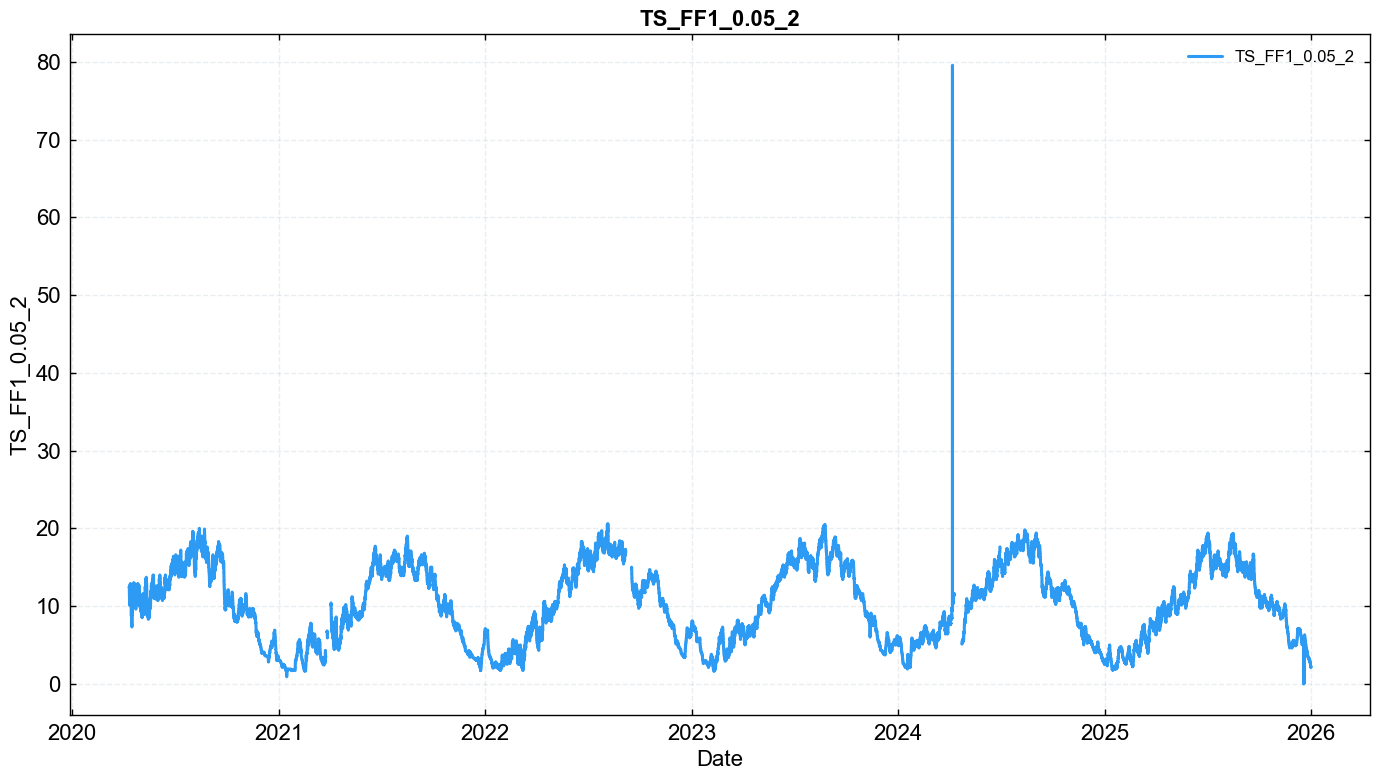

In [14]:
for key, val in mscr.outlier_detection.items():
    val.showplot_cleaned(interactive=False)

### Manual removal
Flag specific timestamps or time ranges for removal - known sensor failures, maintenance windows, logger artefacts. Give `[start, stop]` pairs and/or single timestamps.

**Why this variable needs one.** On 18-19 December 2025 two remote logger-program uploads corrupted the SDI-12 scale: in seven individual minutes *all eleven* SDI-12 channels of the profile depart from their own local median at once, by exactly the same factor — `0.00 ×` on four minutes and `0.50 ×` on three — while the two analogue Campbell 109 thermistors on a different port read a steady 4.8-5.7 °C throughout. Eleven probes between 5 and 60 cm cannot go to zero, or halve, in the same minute for any physical reason. No automatic test reaches them: `0.00 °C` and `3.10 °C` are both plausible December soil temperatures at 0.05 m, so absolute limits cannot see them, and the differencing tests are degenerate here.

> **The windows are written as `[T − 1 min, T]`, and that is deliberate** — see *Timestamp convention*. `ManualRemoval` matches against `TIMESTAMP_MID`, so the closed interval `['2025-12-19 10:38:00', '2025-12-19 10:39:00']` selects exactly the one record whose `TIMESTAMP_END` is `10:39:00`, and a bare timestamp would select nothing. Asserted below.

> ⚠️ **These windows are a *bus* event, not a property of this probe.** They are shared with every SDI-12 channel — which is why they appear identically in the `_1` notebook. Verify them on the preview plot rather than trusting the copy: `REMOVE_DATES` belongs to a sensor.

In [15]:
if SHOW_PARAM_HELP:
    help(dv.outliers.ManualRemoval)

> running ManualRemoval ...

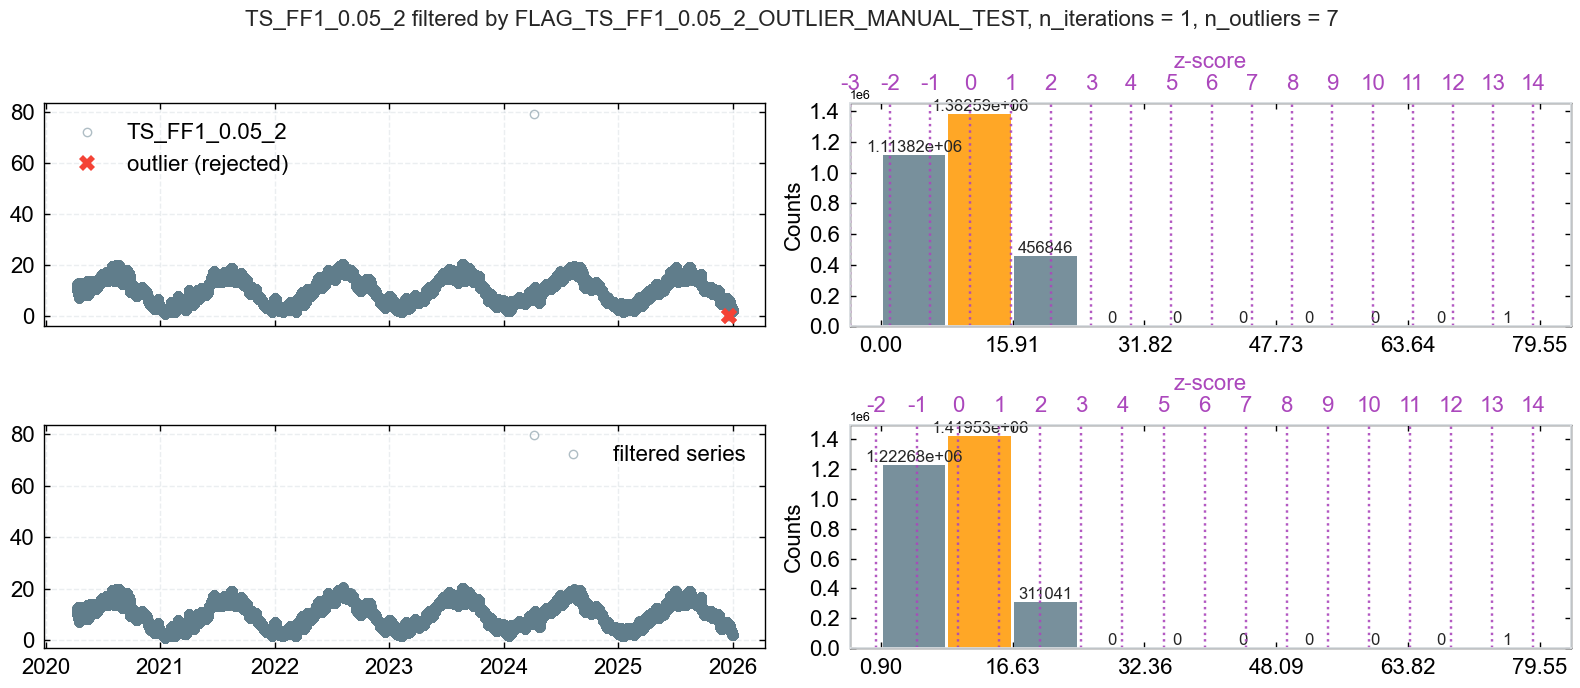

In [16]:
REMOVE_DATES = [
    ['2025-12-18 17:44:00', '2025-12-18 17:45:00'],  # reads 0.00 on all eleven SDI-12 channels
    ['2025-12-19 09:48:00', '2025-12-19 09:49:00'],  # reads exactly half the true value
    ['2025-12-19 09:50:00', '2025-12-19 09:51:00'],  # reads exactly half the true value
    ['2025-12-19 09:56:00', '2025-12-19 09:57:00'],  # reads 0.00 on all eleven SDI-12 channels
    ['2025-12-19 10:30:00', '2025-12-19 10:31:00'],  # reads 0.00 on all eleven SDI-12 channels
    ['2025-12-19 10:35:00', '2025-12-19 10:36:00'],  # reads exactly half the true value
    ['2025-12-19 10:38:00', '2025-12-19 10:39:00'],  # reads 0.00 on all eleven SDI-12 channels
]

# A window that brackets no middle stamp removes nothing at all, silently - so check the shape.
for _w in REMOVE_DATES:
    _s, _e = pd.Timestamp(_w[0]), pd.Timestamp(_w[1])
    assert _e - _s == pd.Timedelta('1min'), (
        f'(!) window {_w} is not the one-minute bracket the TIMESTAMP_MID convention needs')

if REMOVE_DATES:
    mscr.flag_manualremoval_test(remove_dates=REMOVE_DATES, showplot=True, verbose=True)
else:
    print('No manual removal windows for this sensor - skip the addflag cell below.')

In [17]:
if REMOVE_DATES:
    mscr.addflag()

> ++Added flag column FLAG_TS_FF1_0.05_2_OUTLIER_MANUAL_TEST to flag data

### Absolute limits
Flags values outside a fixed physical range `[minval, maxval]`. This is the workhorse test for this channel: the only artefact that is not the December 2025 logger trouble is the April 2024 SDI-12 decode garbage, and every one of those records lands far outside anything the soil can do — this channel's raw maximum is **80.00 °C**.

> ⚠️ **Do not clip instead.** `correction_setto_max_threshold(threshold=30)` would turn an 80 °C decode error into a fabricated 30 °C - a value inside the physical range that nothing downstream could ever identify as fake. A removed value is honest; a clipped one is not.

In [18]:
if SHOW_PARAM_HELP:
    help(dv.outliers.AbsoluteLimits)

> running AbsoluteLimits ...

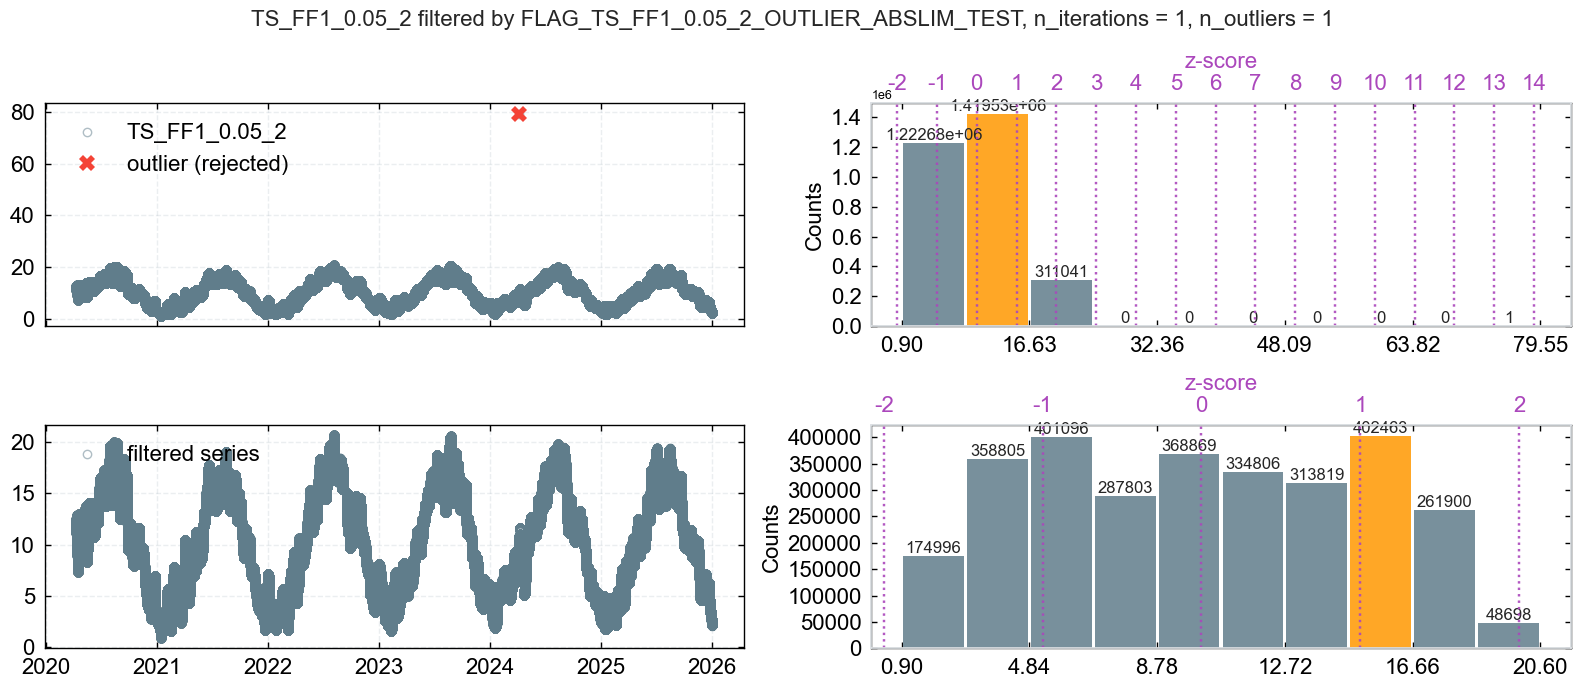

In [19]:
mscr.flag_outliers_abslim_test(minval=TS_MIN, maxval=TS_MAX, showplot=True, verbose=True)

In [20]:
mscr.addflag()

> ++Added flag column FLAG_TS_FF1_0.05_2_OUTLIER_ABSLIM_TEST to flag data

### Other tests (all off)
Left switched off for the reasons given at the top of *Outlier detection*. If you do enable one, report its flagged count **per era** (10MIN before the March 2021 rebuild, 1MIN after) rather than as a total — the two eras behave completely differently. Note also that differencing-based tests compute their differences **after dropping missing records**, so the records flanking every gap are compared across the gap and look like spikes; this record has a 13-day gap in April 2024 and a 10-day one in September 2022.

In [21]:
# Optional, all off by default - read the note above before enabling any of these.
# mscr.flag_outliers_hampel_test(window_length=60 * 24, n_sigma=8, use_differencing=False,
#                                separate_daytime_nighttime=False,
#                                repeat=False, showplot=True, verbose=3)
# mscr.flag_outliers_zscore_test(thres_zscore=4.5, separate_daytime_nighttime=False,
#                                repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_zscore_rolling_test(thres_zscore=4.5, winsize=60 * 24 * 7,
#                                        repeat=True, showplot=True, verbose=True)
# mscr.flag_outliers_localsd_test(n_sd=7, winsize=60 * 24 * 7, constant_sd=False,
#                                 separate_daytime_nighttime=False,
#                                 repeat=False, showplot=True, verbose=True)
# mscr.flag_outliers_increments_zcore_test(thres_zscore=40, repeat=True, showplot=True, verbose=True)
# mscr.addflag()

### Missing values
Not an outlier test - flags missing records so they are counted in the overall `QCF`.

In [22]:
mscr.flag_missingvals_test(verbose=True)

> running MissingValues ...

> MISSING VALUES TEST: Generated new flag variable FLAG_TS_FF1_0.05_2_MISSING_TEST, newly 
calculated from variable TS_FF1_0.05_2, with flag 0 (good values) where TS_FF1_0.05_2 is available, 
flag 2 (bad values) where TS_FF1_0.05_2 is missing.

### Overall quality flag QCF
Aggregate all committed test flags into one overall flag `QCF` (0 = good, 1 = marginal, 2 = bad) and filter the series. Required before corrections and resampling.

In [23]:
mscr.finalize_outlier_detection()

#### Reports

In [24]:
mscr.report_outlier_detection_qcf_evolution()

====================================================================================================
====================

QCF EVOLUTION: SEQUENTIAL TEST APPLICATION

====================================================================================================
====================

Shows how QCF flag distribution changes as tests are applied sequentially

Target variable: TS_FF1_0.05_2

...

----------------------------------------------------------------------------------------------------
--------------------

1     TS_FF1_0.05_2_MISSING                  0        2953258      0            100.00    0.00      
2953258/0/0

2     TS_FF1_0.05_2_OUTLIER_MANUAL           2        2953256      2            100.00    0.00      
2953256/0/2

3     TS_FF1_0.05_2_OUTLIER_ABSLIM           1        2953255      3            100.00    0.00      
2953255/0/3

====================================================================================================
====================

In [25]:
mscr.report_outlier_detection_qcf_flags()

════════════════════════════════════════════════════════════════════════════════════════════════════

INDIVIDUAL TEST FLAG STATISTICS: TS_FF1_0.05_2

════════════════════════════════════════════════════════════════════════════════════════════════════

Total test flags: 3

┌─ REPORT 1A: ALL RECORDS (INCLUDING MISSING VALUES)

...

├─ TS_FF1_0.05_2_OUTLIER_ABSLIM

│  Period          │ Pass (0)        │ Warn (1)        │ Fail (2)        │ Missing

│  -------------------------------------------------------------------------------------

│  OVERALL         │ 2953257 (100.0%) │     0 (  0.0%)  │     1 (  0.0%)  │    0 (  0.0%)

════════════════════════════════════════════════════════════════════════════════════════════════════

In [26]:
mscr.report_outlier_detection_qcf_series()

======================================================================

QCF QUALITY CONTROL REPORT: TS_FF1_0.05_2

======================================================================

[1] TIME PERIOD

Start:  2020-04-10 14:50

...

[4] DATA LOSS ANALYSIS

Records retained after QC: 2953255/2953258 (100.00%)

Data loss from QC:         3/2953258 (0.00%)

Final data coverage:       2953255/3011590 (98.06% of potential)

======================================================================

#### Plots

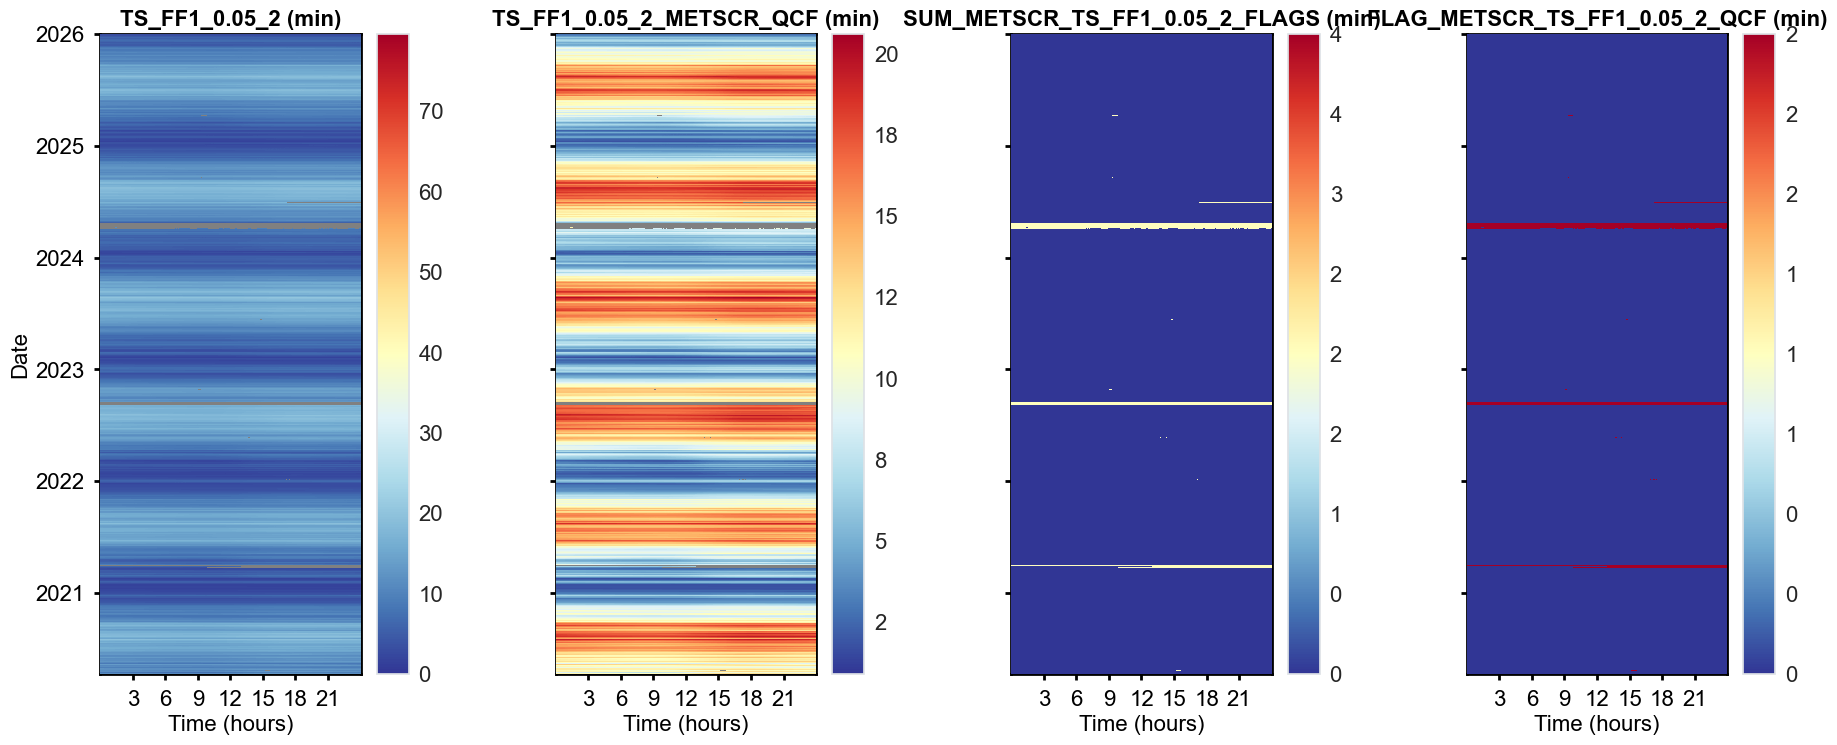

In [27]:
mscr.showplot_outlier_detection_qcf_heatmaps()
# mscr.showplot_outlier_detection_qcf_timeseries()

## 🔧 Corrections
Applied to the high-res, QCF-filtered data. **None of them apply to soil temperature**, and every call below stays commented out. The corrections diive offers are offset removals for radiation and relative humidity, threshold clipping, and setting ranges to a constant - every one of them writes a value the sensor did not measure.

> ⚠️ **Do not set the exact value 0 to missing.** `correction_set_exact_value_to_missing(values=[0])` looks like the obvious way to catch the failed SDI-12 reads, and it is wrong twice over: it would delete every genuine `0.00 °C` reading this soil ever produces, and it would miss the half-scale minutes entirely, because those are not a fixed value at all. That is why those minutes are handled by named manual removal instead.

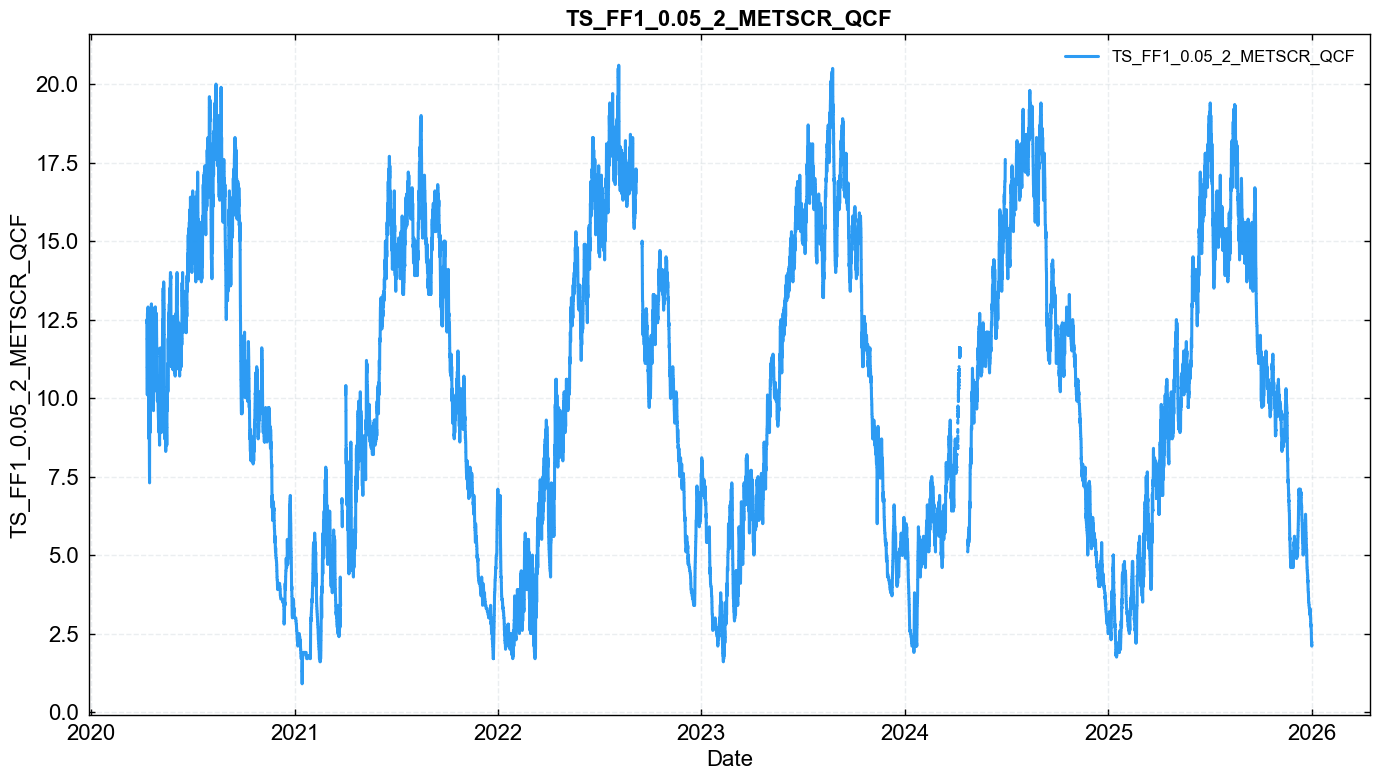

In [28]:
mscr.showplot_cleaned()

Inspect the most frequent values first (read-only, safe to run). This channel **is expected to show heavily repeated values**: the 1MIN era is quantised to 0.05 °C, so a few hundred distinct values carry millions of records, and the 10MIN era is back-filled across ten 1MIN slots. What would be a fault is a *single* value appearing far more often than its neighbours in the seasonal distribution - that is a stuck sensor rather than a coarse one.

In [29]:
for ff in mscr.fields:
    vc = mscr.series_hires_cleaned[ff].value_counts()
    print(f'--- {ff} (top 20 of {mscr.series_hires_cleaned[ff].count():,} records, '
          f'{mscr.series_hires_cleaned[ff].nunique():,} distinct) ---')
    print(vc.head(20))

--- TS_FF1_0.05_2 (top 20 of 2,953,255 records, 2,925 distinct) ---
TS_FF1_0.05_2_METSCR_QCF
4.9     26165
5.0     24690
3.0     24204
5.5     23688
5.4     23671
15.5    23167
5.2     22737
5.3     22643
16.6    22089
14.0    21300
10.1    21265
14.5    21008
15.8    20965
16.5    20944
14.4    20503
13.8    20341
9.0     20276
9.8     20198
6.9     19885
16.2    19724
Name: count, dtype: int64


In [30]:
# All commented out on purpose - none of these apply to soil temperature. See the traps above.
# mscr.correction_setto_max_threshold(threshold=30)
# mscr.correction_setto_min_threshold(threshold=-5)
# mscr.correction_setto_value(dates=[['2022-04-01', '2022-04-05']], value=0, verbose=1)
# mscr.correction_set_exact_value_to_missing(values=[0])
# mscr.showplot_cleaned(interactive=False)

## 🔁 Resampling

### Resample to 30MIN
Resample the screened high-res series to `RESAMPLING_FREQ`. The output timestamp is `TIMESTAMP_END` again (see *Timestamp convention*), ready for upload. **This is the handover point**: everything downstream of here works on the half-hourly series.

> running resample_series_to_freq ...

> Resampling data from min to 30min frequency ...

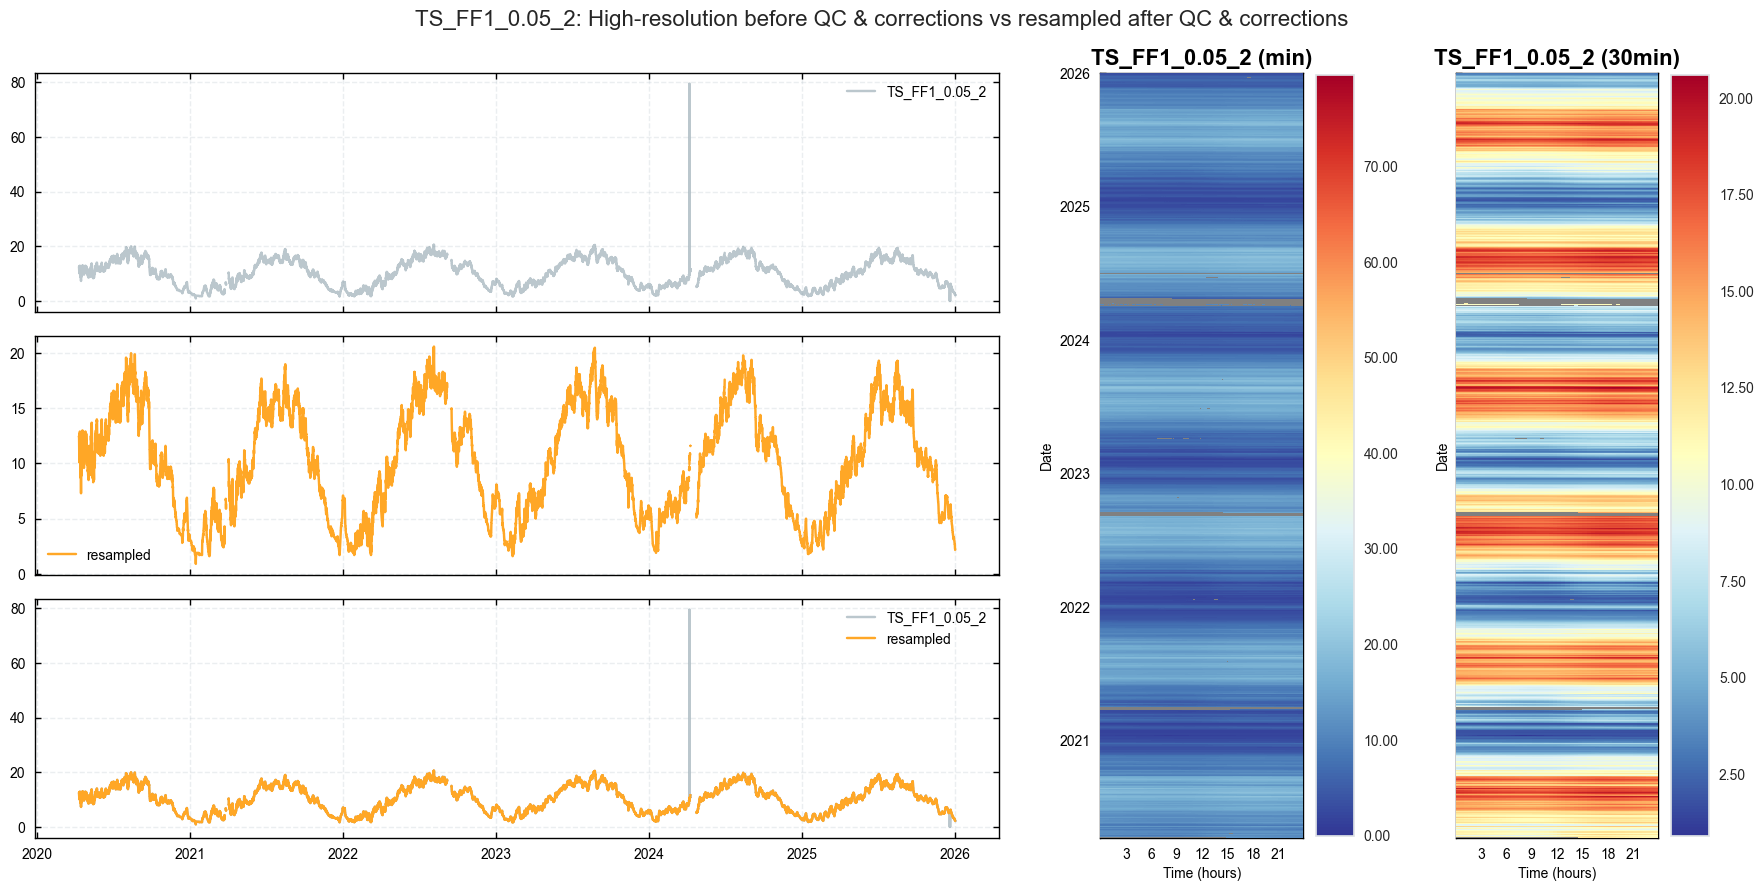

In [31]:
# mincounts_perc stays at the template default of .25, i.e. 7.5 of the 30 records a full
# half hour holds in the 1MIN era. A 30MIN *mean* of a smooth state variable is well
# estimated from a quarter of the records - this series moves a few hundredths of a kelvin
# in half an hour. (A *sum* would be the opposite case and is why the precipitation
# notebook chose differently.)
mscr.resample(to_freqstr=RESAMPLING_FREQ, agg=RESAMPLING_AGG, mincounts_perc=.25)
mscr.showplot_resampled()

### Check the resampled time resolution

In [32]:
for v in mscr.resampled_detailed.keys():
    freq = dv.times.DetectFrequency(index=mscr.resampled_detailed[v].index, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: {freq}')

> Detect frequency: 30min (all methods agree)

PASSED - TS_FF1_0.05_2: 30min


## ⬆️ Upload data to database

**Re-uploading overwrites the same variant - safe to re-run.** With `delete_from_db_before_upload=True` (below), the upload first *deletes*, then writes. The delete is scoped to the exact match `_measurement` + `varname` + `data_version` (`meteoscreening_diive`) over the uploaded time range, so re-screening a period replaces only its previous screened result. It never touches the raw data (different `data_version`, and a different `_raw` bucket), other variables, or other data versions. The delete-first step (rather than a plain overwrite) matters because InfluxDB keys a point by its full tag set: if a tag changed between runs (e.g. `units`, `gain`, `offset`), a plain write would leave the old point as a **duplicate** - the delete removes it regardless of tags.

In [33]:
print(f'Uploading to bucket {BUCKET_PROCESSED}')
for v in mscr.resampled_detailed.keys():
    dbc.upload_singlevar(
        to_bucket=BUCKET_PROCESSED,
        to_measurement=assigned_measurements[v],
        var_df=mscr.resampled_detailed[v],
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        delete_from_db_before_upload=True,
    )

Uploading to bucket ch-lae_processed


> Deleted variables ['TS_FF1_0.05_2'] between 2020-04-10T15:00:00+01:00 and 
2026-01-01T00:00:00+01:00 from measurements ['TS'] in bucket ch-lae_processed.

> Connecting to database ...

> --> UPLOAD TO DATABASE BUCKET ch-lae_processed:  ['TS_FF1_0.05_2']

v Upload finished.

### Verify upload
Download the just-uploaded data back and confirm the time resolution and timestamps. The offset is the same `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the timestamps below should again be local `TIMESTAMP_END` - matching what you screened.

In [34]:
# Fresh variable names so the screened originals (data_detailed etc.) are not overwritten:
check_simple, check_detailed, check_measurements = dbc.download(
    bucket=BUCKET_PROCESSED,
    measurements=[MEASUREMENT],
    fields=FIELDS,
    start=START,
    stop=STOP,
    timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
    data_version='meteoscreening_diive',
)
check_simple

> DOWNLOADING from bucket ch-lae_processed: variables ['TS_FF1_0.05_2'] from measurements ['TS'], 
data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 (timezone
offset to UTC 1)

> Downloaded data for 1 variables:

,TS_FF1_0.05_2
TIMESTAMP_END,
2020-04-10 15:00:00,12.400000
2020-04-10 15:30:00,12.466667
2020-04-10 16:00:00,12.500000
2020-04-10 16:30:00,12.436667
2020-04-10 17:00:00,12.400000
...,...
2025-12-31 22:00:00,2.200000
2025-12-31 22:30:00,2.200000
2025-12-31 23:00:00,2.200000


In [35]:
for v in check_detailed.keys():
    idx = check_detailed[v].index
    freq = dv.times.DetectFrequency(index=idx, verbose=True).get()
    status = 'PASSED' if freq == RESAMPLING_FREQ else '(!) FAILED'
    print(f'{status} - {v}: freq={freq}, first={idx[0]}, last={idx[-1]}')

> Detect frequency: 30min (timedelta, 100% match)

PASSED - TS_FF1_0.05_2: freq=30min, first=2020-04-10 15:00:00, last=2026-01-01 00:00:00


## ✅ End of notebook

In [36]:
_end = datetime.now()
print(f"Finished: {_end.strftime('%Y-%m-%d %H:%M:%S')}  "
      f"(runtime {str(_end - NOTEBOOK_START).split('.')[0]})")

Finished: 2026-07-22 18:34:16  (runtime 0:03:17)


***
### 📝 Notes for this variable

- **Mean, not sum.** `RESAMPLING_AGG = 'mean'` - soil temperature is a state, not a flux.
- **Units are °C**, filegroup `12_meteo_forestfloor`.
- **Sensor identity.** METER **TEROS 12**, installed 19 Mar 2020 at 0.05 m, first logged 2020-04-10 15:00. This is the **same physical probe** that reports `SWC_FF1_0.05_1` — soil water content and this temperature channel come out of one sensor, so a fault in one is worth checking against the other. It is *not* the MPS-2; that is `TS_FF1_0.05_1`.
- **Coverage** 2 503 372 records, 98.98 % over 2020-2025. Shares the profile's outages and lost two extra days to the April 2024 SDI-12 bus failure.
- **Raw range 0.00 … 80.00 °C**, both ends artefacts: `0.00` is the failed-SDI-12-read sentinel, `80.00` is April 2024 decode garbage. The real signal is 1-21 °C.
- **Two raw time resolutions**, 10MIN until the March 2021 logger rebuild and 1MIN after. diive drops any resolution group holding <0.2 % of records and **upsamples the coarser era onto the finest grid** before screening. Report any test's flagged count per era, never as a total.
- **Values are quantised to 0.05 °C** in the 1MIN era. Do not read fine structure into it, and do not expect a differencing-based test to work.
- **A failed sensor read is a number, not a gap.** The CR1000 firmware predates SDI-12 NaN support and the update was declined on 2020-04-10, so a failed read arrives as the true value times a wrong scale factor (`0 ×` or `0.5 ×`). `notna()` does not mean "measured", and neither does "inside the physical range".
- **Deferred to `30_PRODUCTS/`, on the 30MIN data:** the comparison against the rest of the FF1 profile and against air temperature, the placement and offset questions, and any gap handling. This notebook exports gaps where the station was down and does not fill them.

### ♻️ Sibling notebooks
This notebook and `TS_FF1_0.05_1_2020-2025.ipynb` are near-identical because both are SDI-12 channels at the same depth. The `_3`/`_4` notebooks are **not** — see the three marked divergences there before assuming anything carries across.

The standing rule for all of them: **`REMOVE_DATES` belongs to a sensor, not to a variable.** These notebooks are copies of each other with a few settings changed, and carrying a window across a copy deletes good data under a justification written about a different probe.